In [ ]:
import sys
print("Python version")
print(sys.executable)


Python version
c:\Users\User\Desktop\Streamlit\.venv\Scripts\python.exe


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.metrics import (mean_absolute_error, mean_squared_error,r2_score)

In [ ]:
df = pd.read_csv('cardekho_dataset.csv')
df

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [ ]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [ ]:
df.tail()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000
15410,19543,Honda City,Honda,City,2,13000,Dealer,Petrol,Automatic,18.00,1497,117.60,5,1200000


In [ ]:
df.shape

(15411, 14)

In [ ]:
df.dtypes

Unnamed: 0             int64
car_name                 str
brand                    str
model                    str
vehicle_age            int64
km_driven              int64
seller_type              str
fuel_type                str
transmission_type        str
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

In [ ]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  str    
 2   brand              15411 non-null  str    
 3   model              15411 non-null  str    
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  str    
 7   fuel_type          15411 non-null  str    
 8   transmission_type  15411 non-null  str    
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), str(6)
memory usage: 2.3 MB


In [ ]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [ ]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].nunique())


Unnamed: 0:
15411

car_name:
121

brand:
32

model:
120

vehicle_age:
24

km_driven:
3688

seller_type:
3

fuel_type:
5

transmission_type:
2

mileage:
411

engine:
110

max_power:
342

seats:
8

selling_price:
1086


In [ ]:
df['fuel_type'].value_counts()

fuel_type
Petrol      7643
Diesel      7419
CNG          301
LPG           44
Electric       4
Name: count, dtype: int64

In [ ]:
df['transmission_type'].value_counts()

transmission_type
Manual       12225
Automatic     3186
Name: count, dtype: int64

In [ ]:
df = df.drop(columns=['Unnamed: 0', 'car_name'])
df.head()

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


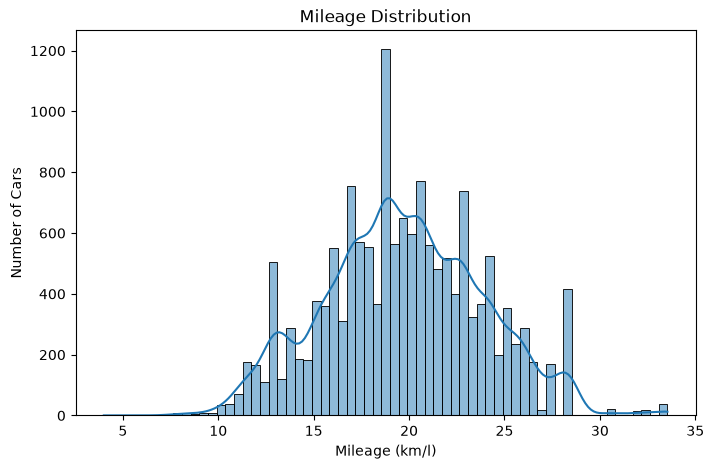

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['mileage'], kde=True)

plt.title('Mileage Distribution')
plt.xlabel('Mileage (km/l)')
plt.ylabel('Number of Cars')

plt.show()

This histogram shows how the mileage values are distributed among the cars. It helps us understand the common mileage range and the overall distribution of the target variable.

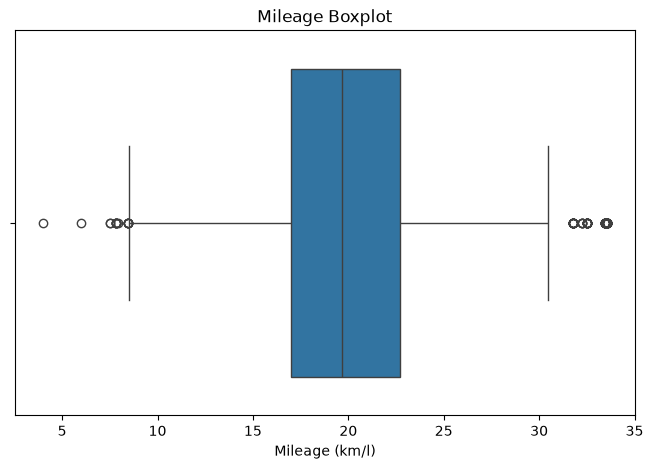

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['mileage'])

plt.title('Mileage Boxplot')
plt.xlabel('Mileage (km/l)')

plt.show()

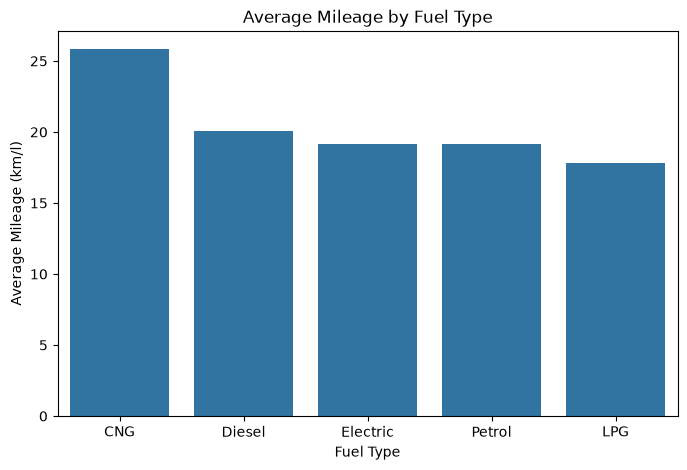

In [ ]:
fuel_mileage = (
    df.groupby('fuel_type')['mileage']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=fuel_mileage.index,
    y=fuel_mileage.values
)

plt.title('Average Mileage by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Mileage (km/l)')

plt.show()

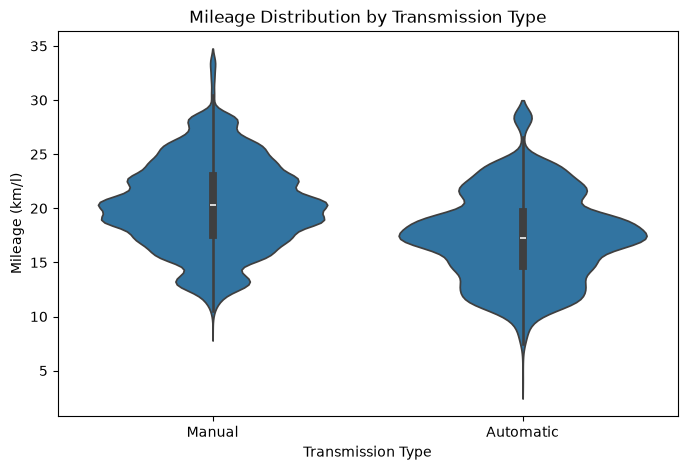

In [ ]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='transmission_type',
    y='mileage'
)

plt.title('Mileage Distribution by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Mileage (km/l)')

plt.show()

In [ ]:
fuel_counts = df['fuel_type'].value_counts()

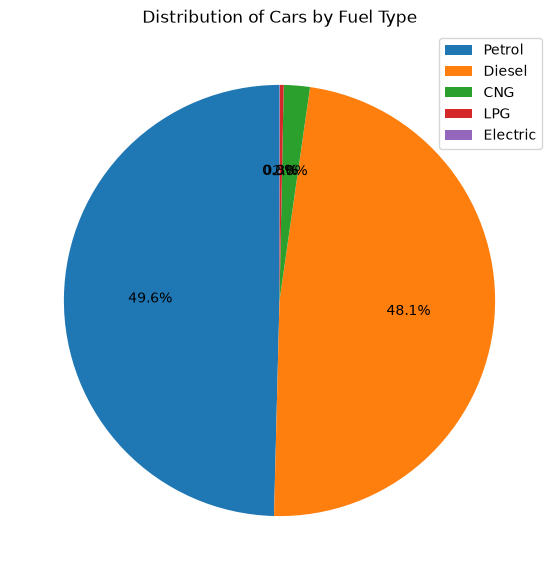

In [ ]:
plt.figure(figsize=(7, 7))

plt.pie(fuel_counts.values, autopct='%1.1f%%', startangle=90)
plt.legend(fuel_counts.index, loc="best")
plt.title('Distribution of Cars by Fuel Type')

plt.show()

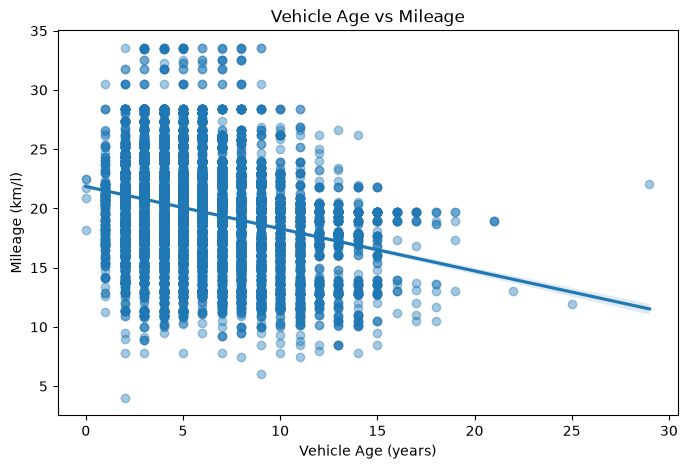

In [ ]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='vehicle_age',
    y='mileage',
    scatter_kws={'alpha': 0.4},
    line_kws={}
)

plt.title('Vehicle Age vs Mileage')
plt.xlabel('Vehicle Age (years)')
plt.ylabel('Mileage (km/l)')

plt.show()

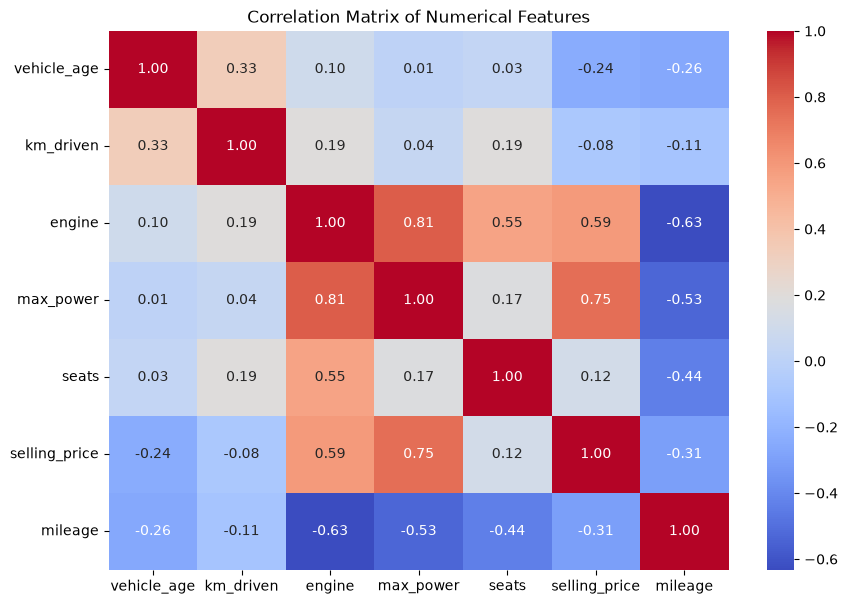

In [ ]:
numeric_cols = [
    'vehicle_age',
    'km_driven',
    'engine',
    'max_power',
    'seats',
    'selling_price',
    'mileage'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Numerical Features')

plt.show()

In [ ]:
df.select_dtypes(include='object').columns

C:\Users\User\AppData\Local\Temp\ipykernel_32756\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type'], dtype='str')

In [ ]:
df = pd.get_dummies(
    df,
    columns=['brand', 'model', 'fuel_type', 'transmission_type'],
    drop_first=True
)

In [ ]:
df.head()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,brand_BMW,brand_Bentley,brand_Datsun,...,model_i10,model_i20,model_redi-GO,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual,seller_type_Individual,seller_type_Trustmark Dealer
0,9,120000,19.70,796,46.30,5,120000,False,False,False,...,False,False,False,False,False,False,True,True,True,False
1,5,20000,18.90,1197,82.00,5,550000,False,False,False,...,False,False,False,False,False,False,True,True,True,False
2,11,60000,17.00,1197,80.00,5,215000,False,False,False,...,False,True,False,False,False,False,True,True,True,False
3,9,37000,20.92,998,67.10,5,226000,False,False,False,...,False,False,False,False,False,False,True,True,True,False
4,6,30000,22.77,1498,98.59,5,570000,False,False,False,...,False,False,False,True,False,False,False,True,False,False


In [ ]:
X = df.drop('mileage', axis=1)
y = df['mileage']

In [ ]:
X = X.astype({col: 'int64' for col in X.select_dtypes(include='bool').columns})

In [ ]:
X.dtypes.value_counts()

int64      162
float64      1
Name: count, dtype: int64

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape

(12328, 163)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [ ]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression
MAE : 1.069754230226974
RMSE: 1.5227628289036075
R2 Score: 0.8686456897963674


In [ ]:
dt = DecisionTreeRegressor(random_state=42,max_depth=10)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree
MAE : 0.4501720006670578
RMSE: 0.8494739046653246
R2 Score: 0.9591229187407859


In [ ]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest
MAE: 0.25285151438510395
RMSE: 0.653294346398409
R2 Score: 0.9758232681454841


In [ ]:
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [ ]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R2 Score:", r2_gb)

Gradient Boosting
MAE : 0.8853397145660526
RMSE: 1.2799478286591721
R2 Score: 0.9071965054687199


In [ ]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [ ]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2 Score:", r2_xgb)

XGBoost
MAE : 0.4125160799883343
RMSE: 0.6865220866117298
R2 Score: 0.9733013795332284


In [ ]:
svr = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.1
)

svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)

In [ ]:
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR")
print("MAE :", mae_svr)
print("RMSE:", rmse_svr)
print("R2 Score:", r2_svr)

SVR
MAE : 0.5537106601757998
RMSE: 1.1808715819034112
R2 Score: 0.9210076313603246


In [ ]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'SVR'
    ],

    'MAE': [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_gb,
        mae_xgb,
        mae_svr
    ],

    'RMSE': [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_gb,
        rmse_xgb,
        rmse_svr
    ],

    'R2 Score': [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_gb,
        r2_xgb,
        r2_svr
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.069754,1.522763,0.868646
1,Decision Tree,0.450172,0.849474,0.959123
2,Random Forest,0.252852,0.653294,0.975823
3,Gradient Boosting,0.885340,1.279948,0.907197
4,XGBoost,0.412516,0.686522,0.973301
5,SVR,0.553711,1.180872,0.921008


In [ ]:
# Training predictions
train_pred = rf.predict(X_train)

# Testing predictions
test_pred = rf.predict(X_test)

print("Training R²:", r2_score(y_train, train_pred))
print("Testing R²:", r2_score(y_test, test_pred))

print("Training MAE:", mean_absolute_error(y_train, train_pred))
print("Testing MAE:", mean_absolute_error(y_test, test_pred))

Training R²: 0.9962349521650131
Testing R²: 0.9758232681454841
Training MAE: 0.09181068638114151
Testing MAE: 0.25285151438510384


In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R2:", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Best CV R2: 0.9710503808080432


In [ ]:
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

In [ ]:

mae = mean_absolute_error(y_test, y_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest Results")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Tuned Random Forest Results
MAE : 0.2626869368359921
RMSE: 0.6612781632277119
R²  : 0.975228736597729


In [ ]:
print("Original Random Forest")
print("MAE :", 0.252674)
print("RMSE:", 0.652823)
print("R²  :", 0.975858)

print("\nTuned Random Forest")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Original Random Forest
MAE : 0.252674
RMSE: 0.652823
R²  : 0.975858

Tuned Random Forest
MAE : 0.2626869368359921
RMSE: 0.6612781632277119
R²  : 0.975228736597729


In [ ]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

final_model = rf

print("Final Model: Random Forest Regressor")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Final Model: Random Forest Regressor
MAE : 0.25285151438510395
RMSE: 0.653294346398409
R² Score: 0.9758232681454841


In [ ]:
y_pred_original = final_model.predict(X_test)

comparison = pd.DataFrame({
    'Actual Mileage': y_test.values,
    'Predicted Mileage': y_pred_original
})

comparison.head(10)

,Actual Mileage,Predicted Mileage
0,20.36,20.360000
1,27.39,27.288067
2,20.77,20.770000
3,18.40,17.795067
4,19.70,19.700000
5,13.93,13.621333
6,18.90,18.900000
7,22.50,22.500000
8,16.80,16.800000
9,15.06,16.282833


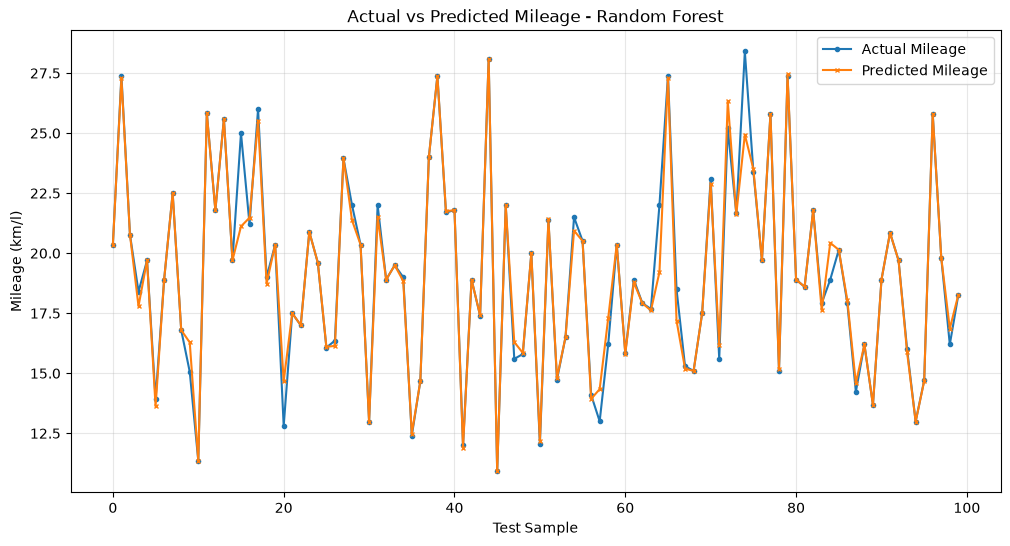

In [ ]:
y_pred = y_pred_rf

actual = y_test.iloc[:100].values
predicted = y_pred[:100]

plt.figure(figsize=(12, 6))

plt.plot(actual, label='Actual Mileage', marker='o', markersize=3)
plt.plot(predicted, label='Predicted Mileage', marker='x', markersize=3)

plt.xlabel('Test Sample')
plt.ylabel('Mileage (km/l)')
plt.title('Actual vs Predicted Mileage - Random Forest')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

pickle the model


In [ ]:
import pickle
with open('model.pkl', 'wb') as file:
        pickle.dump(final_model, file)